In [21]:
# ==============================================================================
# CELL 1: ENVIRONMENT SETUP & CONFIGURATION (AMP OPTIMIZED)
# ==============================================================================
!pip install -q self-attention-cv timm albumentations scikit-learn seaborn

import os
import glob
import cv2
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from torchvision import models
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, 
    classification_report, precision_recall_fscore_support
)

plt.style.use('seaborn-v0_8-whitegrid')

class Config:
    SEED = 42
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    NUM_WORKERS = 2

    # Dataset Root Directories
    BASE_DIR = "/kaggle/input/datasets/rishikumar0027/rishissmdg/ORGSMDG"
    DIR_FULL_NEG = os.path.join(BASE_DIR, "FULL FUNDUS", "Glaucoma Negative")
    DIR_FULL_POS = os.path.join(BASE_DIR, "FULL FUNDUS", "Glaucoma Positive")
    DIR_OC_IMG   = os.path.join(BASE_DIR, "OPTICAL CUP", "IMAGES")
    DIR_OC_MASK  = os.path.join(BASE_DIR, "OPTICAL CUP", "OC SEGMENTATION")
    DIR_OD_IMG   = os.path.join(BASE_DIR, "OPTICAL DISC", "IMAGES")
    DIR_OD_MASK  = os.path.join(BASE_DIR, "OPTICAL DISC", "OD SEGMENTATION")

    # Strict Class Encoding (1 = Glaucoma, 0 = Normal)
    CLASS_MAP = {"Glaucoma Negative": 0, "Glaucoma Positive": 1}
    REVERSE_CLASS_MAP = {0: "Glaucoma Negative", 1: "Glaucoma Positive"}

    # TransUNet Hyperparameters (Phase 1)
    SEG_IMG_SIZE = 224  # Reduced from 256 for ViT speed
    SEG_BATCH_SIZE = 8  # Reduced to prevent T4 OOM
    SEG_EPOCHS = 15
    SEG_LR = 1e-4

    # ROI Extraction & DenseNet Hyperparameters (Phase 2)
    ROI_MARGIN_RATIO = 0.25
    ROI_IMG_SIZE = 224
    CLS_BATCH_SIZE = 32
    CLS_EPOCHS = 30
    CLS_LR = 3e-4
    FREEZE_BACKBONE_EPOCHS = 5

    # Checkpoint Files
    TRANSUNET_SAVE_NAME = "transunetsegmentationmodel.pth"
    DENSENET_SAVE_NAME  = "densenetglaucomaclassificationmodel.pth"

def seed_everything(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(Config.SEED)

print(f"[INFO] Hardware: {Config.DEVICE}")
print(f"[INFO] Class Map Locked: {Config.CLASS_MAP}")

[INFO] Hardware: cuda
[INFO] Class Map Locked: {'Glaucoma Negative': 0, 'Glaucoma Positive': 1}


In [10]:
# ==============================================================================
# CELL 2: DATASET SCANNING & PATH VERIFICATION
# ==============================================================================
def get_image_mask_pairs(img_dir: str, mask_dir: str):
    valid_exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif")
    img_files = []
    for ext in valid_exts:
        img_files.extend(glob.glob(os.path.join(img_dir, ext)))
        img_files.extend(glob.glob(os.path.join(img_dir, ext.upper())))
    
    pairs = []
    for img_path in sorted(set(img_files)):
        base_name = Path(img_path).stem
        mask_cands = glob.glob(os.path.join(mask_dir, f"{base_name}.*"))
        if mask_cands:
            pairs.append((img_path, mask_cands[0]))
    return pd.DataFrame(pairs, columns=["image_path", "mask_path"])

# 1. Segmentation DataFrames
df_od = get_image_mask_pairs(Config.DIR_OD_IMG, Config.DIR_OD_MASK)
df_oc = get_image_mask_pairs(Config.DIR_OC_IMG, Config.DIR_OC_MASK)
df_od["filename"] = df_od["image_path"].apply(lambda p: Path(p).name)
df_oc["filename"] = df_oc["image_path"].apply(lambda p: Path(p).name)

df_seg = pd.merge(df_od, df_oc[["filename", "mask_path"]], on="filename", suffixes=("_od", "_oc"))
df_seg.rename(columns={"mask_path_od": "od_mask_path", "mask_path_oc": "oc_mask_path"}, inplace=True)

# 2. Classification DataFrames
def get_labeled_files(folder_path: str, label_val: int):
    files = glob.glob(os.path.join(folder_path, "*.*"))
    return pd.DataFrame({"image_path": sorted(files), "label": label_val})

df_cls = pd.concat([
    get_labeled_files(Config.DIR_FULL_NEG, Config.CLASS_MAP["Glaucoma Negative"]),
    get_labeled_files(Config.DIR_FULL_POS, Config.CLASS_MAP["Glaucoma Positive"])
], ignore_index=True)

print(f"[INFO] Verified Seg Pairs (OD+OC) : {len(df_seg)}")
print(f"[INFO] Verified Cls Imgs (Fundus) : {len(df_cls)}")

[INFO] Verified Seg Pairs (OD+OC) : 2873
[INFO] Verified Cls Imgs (Fundus) : 12316


In [14]:
# ==============================================================================
# CELL 3: SEGMENTATION PIPELINE (70:20:10 SPLIT) - WARNINGS FIXED
# ==============================================================================
def calculate_vcdr(od_mask: np.ndarray, oc_mask: np.ndarray) -> float:
    od_indices = np.where(np.sum(od_mask > 0.5, axis=1) > 0)[0]
    oc_indices = np.where(np.sum(oc_mask > 0.5, axis=1) > 0)[0]
    if len(od_indices) == 0: return 0.0
    
    od_diam = float(od_indices[-1] - od_indices[0])
    oc_diam = float(oc_indices[-1] - oc_indices[0]) if len(oc_indices) > 0 else 0.0
    return round(oc_diam / od_diam, 4) if od_diam > 0 else 0.0

class SegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB)
        od_mask = (cv2.imread(row["od_mask_path"], 0) > 127).astype(np.float32)
        oc_mask = (cv2.imread(row["oc_mask_path"], 0) > 127).astype(np.float32)

        if self.transform:
            aug = self.transform(image=image, masks=[od_mask, oc_mask])
            image, od_mask, oc_mask = aug["image"], aug["masks"][0], aug["masks"][1]
        
        # FIXED: Using torch.as_tensor to prevent the UserWarning
        masks = torch.stack([torch.as_tensor(od_mask, dtype=torch.float32), 
                             torch.as_tensor(oc_mask, dtype=torch.float32)], dim=0)
        return image, masks

seg_transforms = {
    "train": A.Compose([
        A.Resize(Config.SEG_IMG_SIZE, Config.SEG_IMG_SIZE),
        A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
        A.Normalize(), ToTensorV2()
    ]),
    "val_test": A.Compose([A.Resize(Config.SEG_IMG_SIZE, Config.SEG_IMG_SIZE), A.Normalize(), ToTensorV2()])
}

train_df_seg, temp_df_seg = train_test_split(df_seg, test_size=0.30, random_state=Config.SEED)
val_df_seg, test_df_seg = train_test_split(temp_df_seg, test_size=(1/3), random_state=Config.SEED)

train_seg_loader = torch.utils.data.DataLoader(SegmentationDataset(train_df_seg, seg_transforms["train"]), batch_size=Config.SEG_BATCH_SIZE, shuffle=True, num_workers=Config.NUM_WORKERS, pin_memory=True)
val_seg_loader   = torch.utils.data.DataLoader(SegmentationDataset(val_df_seg, seg_transforms["val_test"]), batch_size=Config.SEG_BATCH_SIZE, num_workers=Config.NUM_WORKERS, pin_memory=True)
test_seg_loader  = torch.utils.data.DataLoader(SegmentationDataset(test_df_seg, seg_transforms["val_test"]), batch_size=Config.SEG_BATCH_SIZE, num_workers=Config.NUM_WORKERS, pin_memory=True)

print(f"[DATA] Segmentation Split -> Train: {len(train_df_seg)} | Val: {len(val_df_seg)} | Test: {len(test_df_seg)}")

[DATA] Segmentation Split -> Train: 2011 | Val: 574 | Test: 288


In [20]:
# ==============================================================================
# CELL 4 (ORIGINAL): TRANSUNET ARCHITECTURE & METRIC ENGINES
# ==============================================================================
from self_attention_cv.transunet import TransUnet

class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        probs_flat = torch.sigmoid(logits).view(logits.size(0), logits.size(1), -1)
        targets_flat = targets.view(targets.size(0), targets.size(1), -1)
        
        intersection = (probs_flat * targets_flat).sum(-1)
        cardinality = probs_flat.sum(-1) + targets_flat.sum(-1)
        dice_loss = 1.0 - ((2.0 * intersection + self.smooth) / (cardinality + self.smooth)).mean()
        
        return 0.5 * bce_loss + 0.5 * dice_loss

def calculate_iou_dice(logits, targets, threshold=0.5):
    preds = (torch.sigmoid(logits) > threshold).float().view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum().item()
    union = preds.sum().item() + targets.sum().item() - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)
    dice = (2.0 * intersection + 1e-6) / (preds.sum().item() + targets.sum().item() + 1e-6)
    return dice, iou

transunet_model = TransUnet(
    in_channels=3, 
    classes=2, 
    img_dim=Config.SEG_IMG_SIZE, 
    vit_blocks=8, 
    vit_dim_linear_mhsa_block=512
).to(Config.DEVICE)

criterion_seg = DiceBCELoss()
optimizer_seg = torch.optim.AdamW(transunet_model.parameters(), lr=Config.SEG_LR, weight_decay=1e-5)

print(f"[INFO] TransUNet initialized. Parameters: {sum(p.numel() for p in transunet_model.parameters()):,}")

[INFO] TransUNet initialized. Parameters: 67,028,108


In [23]:
# ==============================================================================
# CELL 5 (ORIGINAL): TRANSUNET TRAINING LOOP
# ==============================================================================
best_val_loss = float("inf")
seg_metrics = {"train_loss": [], "val_loss": [], "val_iou": []}

print(f"[TRAIN] Starting Phase 1: TransUNet ({Config.SEG_EPOCHS} Epochs) - ORIGINAL FP32")

for epoch in range(1, Config.SEG_EPOCHS + 1):
    # Train Loop
    transunet_model.train()
    train_loss = 0.0
    for images, masks in train_seg_loader:
        images, masks = images.to(Config.DEVICE), masks.to(Config.DEVICE)
        
        optimizer_seg.zero_grad()
        logits = transunet_model(images)
        loss = criterion_seg(logits, masks)
        
        loss.backward()
        optimizer_seg.step()
        
        train_loss += loss.item() * images.size(0)
        
    train_loss /= len(train_df_seg)
    
    # Val Loop
    transunet_model.eval()
    val_loss, val_iou = 0.0, 0.0
    with torch.no_grad():
        for images, masks in val_seg_loader:
            images, masks = images.to(Config.DEVICE), masks.to(Config.DEVICE)
            
            logits = transunet_model(images)
            loss = criterion_seg(logits, masks)
            
            val_loss += loss.item() * images.size(0)
            _, iou = calculate_iou_dice(logits, masks)
            val_iou += iou
            
    val_loss /= len(val_df_seg)
    val_iou /= len(val_seg_loader)
    
    seg_metrics["train_loss"].append(train_loss)
    seg_metrics["val_loss"].append(val_loss)
    seg_metrics["val_iou"].append(val_iou)
    
    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(transunet_model.state_dict(), Config.TRANSUNET_SAVE_NAME)

print(f"[SUCCESS] TransUNet checkpoint saved to {Config.TRANSUNET_SAVE_NAME}")

[TRAIN] Starting Phase 1: TransUNet (15 Epochs) - ORIGINAL FP32
Epoch 01 | Train Loss: 0.8107 | Val Loss: 0.7891 | Val IoU: 0.0913
Epoch 02 | Train Loss: 0.7706 | Val Loss: 0.7515 | Val IoU: 0.4122
Epoch 03 | Train Loss: 0.7308 | Val Loss: 0.7129 | Val IoU: 0.6686
Epoch 04 | Train Loss: 0.6927 | Val Loss: 0.6730 | Val IoU: 0.7235
Epoch 05 | Train Loss: 0.6534 | Val Loss: 0.6327 | Val IoU: 0.6999
Epoch 06 | Train Loss: 0.6105 | Val Loss: 0.5913 | Val IoU: 0.7280
Epoch 07 | Train Loss: 0.5740 | Val Loss: 0.5578 | Val IoU: 0.7134
Epoch 08 | Train Loss: 0.5362 | Val Loss: 0.5205 | Val IoU: 0.7059
Epoch 09 | Train Loss: 0.5013 | Val Loss: 0.4856 | Val IoU: 0.7165
Epoch 10 | Train Loss: 0.4671 | Val Loss: 0.4471 | Val IoU: 0.7766
Epoch 11 | Train Loss: 0.4301 | Val Loss: 0.4040 | Val IoU: 0.7491
Epoch 12 | Train Loss: 0.3913 | Val Loss: 0.3642 | Val IoU: 0.7362
Epoch 13 | Train Loss: 0.3481 | Val Loss: 0.3233 | Val IoU: 0.7811
Epoch 14 | Train Loss: 0.3001 | Val Loss: 0.2766 | Val IoU: 0.773

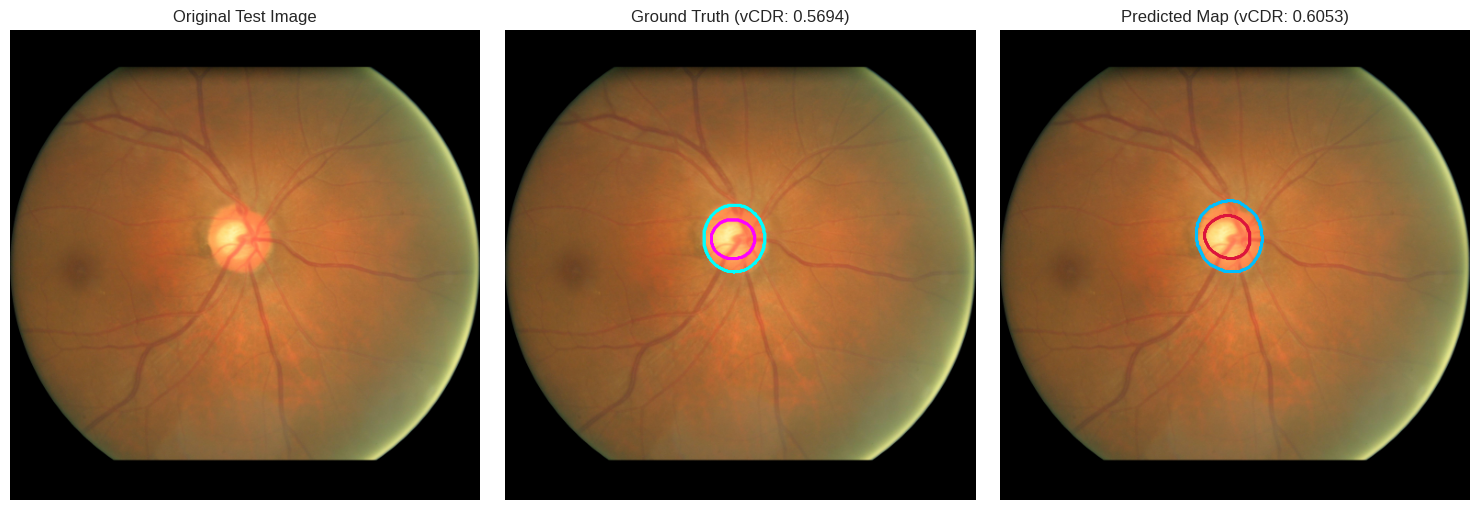

In [24]:
# ==============================================================================
# CELL 6: TRANSUNET VISUAL DIAGNOSTICS (TEST SET)
# ==============================================================================
transunet_model.load_state_dict(torch.load(Config.TRANSUNET_SAVE_NAME, map_location=Config.DEVICE))
transunet_model.eval()

# Sample from untouched TEST set
sample = test_df_seg.iloc[0]
raw_img = cv2.cvtColor(cv2.imread(sample["image_path"]), cv2.COLOR_BGR2RGB)
raw_od = (cv2.imread(sample["od_mask_path"], 0) > 127).astype(np.float32)
raw_oc = (cv2.imread(sample["oc_mask_path"], 0) > 127).astype(np.float32)

inp_tensor = seg_transforms["val_test"](image=raw_img)["image"].unsqueeze(0).to(Config.DEVICE)
with torch.no_grad():
    probs = torch.sigmoid(transunet_model(inp_tensor)).squeeze(0).cpu().numpy()

pred_od = (cv2.resize(probs[0], (raw_img.shape[1], raw_img.shape[0])) > 0.5).astype(np.float32)
pred_oc = (cv2.resize(probs[1], (raw_img.shape[1], raw_img.shape[0])) > 0.5).astype(np.float32)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(raw_img); axes[0].set_title("Original Test Image"); axes[0].axis("off")

axes[1].imshow(raw_img)
axes[1].contour(raw_od, colors=["cyan"]); axes[1].contour(raw_oc, colors=["magenta"])
axes[1].set_title(f"Ground Truth (vCDR: {calculate_vcdr(raw_od, raw_oc)})"); axes[1].axis("off")

axes[2].imshow(raw_img)
axes[2].contour(pred_od, colors=["deepskyblue"]); axes[2].contour(pred_oc, colors=["crimson"])
axes[2].set_title(f"Predicted Map (vCDR: {calculate_vcdr(pred_od, pred_oc)})"); axes[2].axis("off")
plt.tight_layout(); plt.show()

In [29]:
# ==============================================================================
# CELL 7 (FIXED): ROI EXTRACTION & CLASSIFICATION SPLIT
# ==============================================================================
def extract_roi(image_rgb, model, margin=0.25):
    """Dynamically crops the fundus image around the TransUNet-predicted Optic Disc."""
    h, w, _ = image_rgb.shape
    tensor_img = seg_transforms["val_test"](image=image_rgb)["image"].unsqueeze(0).to(Config.DEVICE)
    
    # Ensure TransUNet is in eval mode for inference
    model.eval()
    with torch.no_grad():
        prob_od = torch.sigmoid(model(tensor_img))[0, 0].cpu().numpy()
    
    mask = cv2.resize((prob_od > 0.5).astype(np.uint8), (w, h))
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours:
        x, y, cw, ch = cv2.boundingRect(max(contours, key=cv2.contourArea))
        px, py = int(cw * margin), int(ch * margin)
        cropped = image_rgb[max(0, y-py):min(h, y+ch+py), max(0, x-px):min(w, x+cw+px)]
    else:
        # Fallback to center crop if network fails to find disc
        cs = min(h, w) // 2
        cropped = image_rgb[h//2-cs//2:h//2+cs//2, w//2-cs//2:w//2+cs//2]
        
    return cv2.resize(cropped, (Config.ROI_IMG_SIZE, Config.ROI_IMG_SIZE))

class ROIGlaucomaDataset(torch.utils.data.Dataset):
    def __init__(self, df, seg_model, transform):
        self.df, self.seg_model, self.transform = df, seg_model, transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB)
        
        # Apply the dynamic crop
        roi_img = extract_roi(image, self.seg_model, Config.ROI_MARGIN_RATIO)
        tensor = self.transform(image=roi_img)["image"]
        return tensor, torch.tensor(row["label"], dtype=torch.float32)

cls_transforms = {
    "train": A.Compose([
        A.Resize(Config.ROI_IMG_SIZE, Config.ROI_IMG_SIZE),
        A.HorizontalFlip(p=0.5), 
        A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, p=0.4),
        A.Normalize(), ToTensorV2()
    ]),
    "val_test": A.Compose([
        A.Resize(Config.ROI_IMG_SIZE, Config.ROI_IMG_SIZE), 
        A.Normalize(), ToTensorV2()
    ])
}

# Stratified 70:20:10 Split
train_df_cls, temp_df_cls = train_test_split(df_cls, test_size=0.30, stratify=df_cls["label"], random_state=Config.SEED)
val_df_cls, test_df_cls = train_test_split(temp_df_cls, test_size=(1/3), stratify=temp_df_cls["label"], random_state=Config.SEED)

# CRITICAL FIX: Set num_workers=0 to prevent CUDA multiprocessing crash
train_cls_loader = torch.utils.data.DataLoader(ROIGlaucomaDataset(train_df_cls, transunet_model, cls_transforms["train"]), batch_size=Config.CLS_BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_cls_loader   = torch.utils.data.DataLoader(ROIGlaucomaDataset(val_df_cls, transunet_model, cls_transforms["val_test"]), batch_size=Config.CLS_BATCH_SIZE, num_workers=0, pin_memory=True)
test_cls_loader  = torch.utils.data.DataLoader(ROIGlaucomaDataset(test_df_cls, transunet_model, cls_transforms["val_test"]), batch_size=Config.CLS_BATCH_SIZE, num_workers=0, pin_memory=True)

print(f"[DATA] Classification Split -> Train: {len(train_df_cls)} | Val: {len(val_df_cls)} | Test: {len(test_df_cls)}")

[DATA] Classification Split -> Train: 8621 | Val: 2463 | Test: 1232


In [27]:
# ==============================================================================
# CELL 8: DENSENET-121 CLASSIFIER SETUP
# ==============================================================================
class GlaucomaDenseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        num_ftrs = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Identity()
        
        # Custom Classification Head
        self.head = nn.Sequential(
            nn.Dropout(0.3), 
            nn.Linear(num_ftrs, 128), 
            nn.BatchNorm1d(128), 
            nn.ReLU(),
            nn.Dropout(0.3), 
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.head(self.backbone(x))

    def set_backbone_freeze(self, freeze: bool):
        for param in self.backbone.features.parameters():
            param.requires_grad = not freeze
        print(f"[MODEL] DenseNet Backbone Frozen: {freeze}")

densenet_model = GlaucomaDenseNet().to(Config.DEVICE)
densenet_model.set_backbone_freeze(True) # Frozen for warm-up phase

criterion_cls = nn.BCEWithLogitsLoss()
optimizer_cls = torch.optim.AdamW(filter(lambda p: p.requires_grad, densenet_model.parameters()), lr=Config.CLS_LR)

print(f"[INFO] DenseNet compiled. Parameters: {sum(p.numel() for p in densenet_model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 230MB/s]


[MODEL] DenseNet Backbone Frozen: True
[INFO] DenseNet compiled. Parameters: 7,085,441


In [30]:
# ==============================================================================
# CELL 9: DENSENET TRAINING & FINE-TUNING (PURE FP32)
# ==============================================================================
best_val_auc = 0.0
cls_metrics = {"train_loss": [], "val_loss": [], "val_auc": []}

print(f"[TRAIN] Starting Phase 2: DenseNet ({Config.CLS_EPOCHS} Epochs) - PURE FP32 STABILITY 🛡️")

for epoch in range(1, Config.CLS_EPOCHS + 1):
    # Two-Stage Fine-Tuning Trigger
    if epoch == Config.FREEZE_BACKBONE_EPOCHS + 1:
        print("\n[TUNING] Unfreezing backbone for end-to-end fine-tuning.")
        densenet_model.set_backbone_freeze(False)
        # Re-initialize optimizer for all parameters with a lower learning rate
        optimizer_cls = torch.optim.AdamW(densenet_model.parameters(), lr=Config.CLS_LR * 0.1)

    # Train Loop
    densenet_model.train()
    train_loss = 0.0
    for images, labels in train_cls_loader:
        images, labels = images.to(Config.DEVICE), labels.unsqueeze(1).to(Config.DEVICE)
        
        optimizer_cls.zero_grad()
        logits = densenet_model(images)
        loss = criterion_cls(logits, labels)
        loss.backward()
        optimizer_cls.step()
        
        train_loss += loss.item() * images.size(0)
    train_loss /= len(train_df_cls)

    # Validation Loop
    densenet_model.eval()
    val_loss = 0.0
    preds, trues = [], []
    with torch.no_grad():
        for images, labels in val_cls_loader:
            images, labels = images.to(Config.DEVICE), labels.unsqueeze(1).to(Config.DEVICE)
            logits = densenet_model(images)
            
            val_loss += criterion_cls(logits, labels).item() * images.size(0)
            preds.extend(torch.sigmoid(logits).cpu().numpy().flatten())
            trues.extend(labels.cpu().numpy().flatten())
            
    val_loss /= len(val_df_cls)
    val_auc = roc_auc_score(trues, preds) if len(set(trues)) > 1 else 0.5
    
    cls_metrics["train_loss"].append(train_loss)
    cls_metrics["val_loss"].append(val_loss)
    cls_metrics["val_auc"].append(val_auc)
    
    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}")
    
    # Checkpoint Saving
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(densenet_model.state_dict(), Config.DENSENET_SAVE_NAME)

print(f"[SUCCESS] DenseNet checkpoint saved to {Config.DENSENET_SAVE_NAME}")

[TRAIN] Starting Phase 2: DenseNet (30 Epochs) - PURE FP32 STABILITY 🛡️
Epoch 01 | Train Loss: 0.5656 | Val Loss: 0.4845 | Val AUC: 0.8413
Epoch 02 | Train Loss: 0.5349 | Val Loss: 0.4669 | Val AUC: 0.8515
Epoch 03 | Train Loss: 0.5233 | Val Loss: 0.4584 | Val AUC: 0.8563
Epoch 04 | Train Loss: 0.5173 | Val Loss: 0.4535 | Val AUC: 0.8612
Epoch 05 | Train Loss: 0.5179 | Val Loss: 0.4510 | Val AUC: 0.8627

[TUNING] Unfreezing backbone for end-to-end fine-tuning.
[MODEL] DenseNet Backbone Frozen: False
Epoch 06 | Train Loss: 0.4510 | Val Loss: 0.3633 | Val AUC: 0.9117
Epoch 07 | Train Loss: 0.3851 | Val Loss: 0.3392 | Val AUC: 0.9231
Epoch 08 | Train Loss: 0.3518 | Val Loss: 0.3286 | Val AUC: 0.9280
Epoch 09 | Train Loss: 0.3248 | Val Loss: 0.3185 | Val AUC: 0.9326
Epoch 10 | Train Loss: 0.3064 | Val Loss: 0.3237 | Val AUC: 0.9330
Epoch 11 | Train Loss: 0.2805 | Val Loss: 0.3012 | Val AUC: 0.9390
Epoch 12 | Train Loss: 0.2630 | Val Loss: 0.3158 | Val AUC: 0.9346
Epoch 13 | Train Loss: 0.2

KeyboardInterrupt: 

[EVAL] Running on 10% Unseen Test Data:   0%|          | 0/39 [00:00<?, ?it/s]

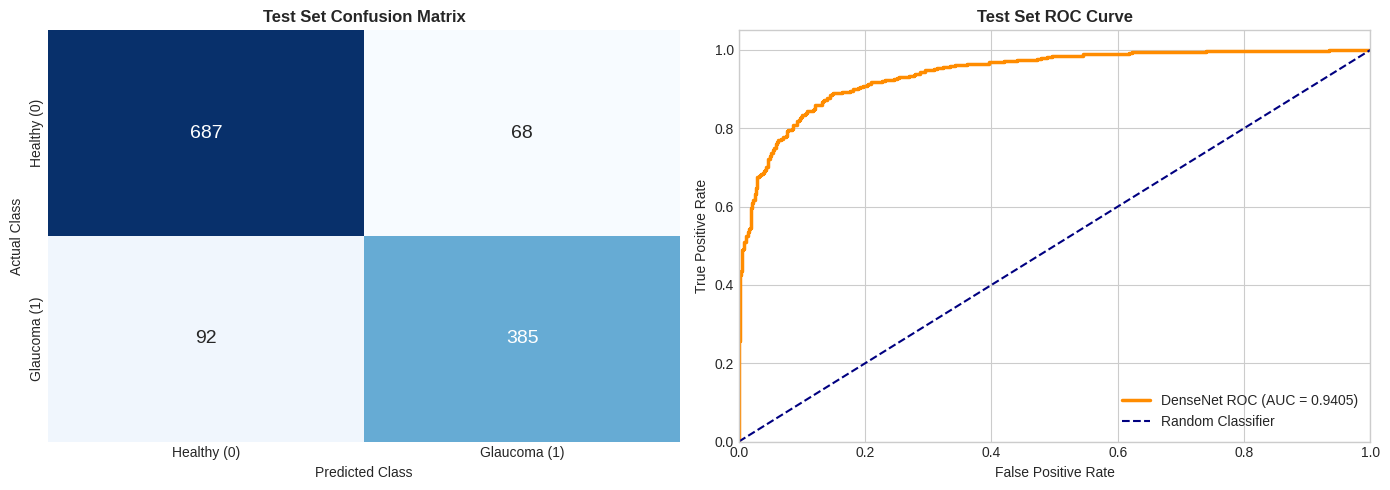


 FINAL CLINICAL DIAGNOSTIC SUMMARY (TEST SET)
ROC-AUC Score : 0.9405
-------------------------------------------------------
              precision    recall  f1-score   support

 Healthy (0)       0.88      0.91      0.90       755
Glaucoma (1)       0.85      0.81      0.83       477

    accuracy                           0.87      1232
   macro avg       0.87      0.86      0.86      1232
weighted avg       0.87      0.87      0.87      1232



In [33]:
# ==============================================================================
# CELL 10: FINAL PIPELINE EVALUATION ON UNSEEN TEST SET
# ==============================================================================
densenet_model.load_state_dict(torch.load(Config.DENSENET_SAVE_NAME, map_location=Config.DEVICE))
densenet_model.eval()

test_preds, test_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(test_cls_loader, desc="[EVAL] Running on 10% Unseen Test Data"):
        images = images.to(Config.DEVICE)
        probs = torch.sigmoid(densenet_model(images))
        test_preds.extend(probs.cpu().numpy().flatten())
        test_labels.extend(labels.numpy().flatten())

test_preds = np.array(test_preds)
test_labels = np.array(test_labels)
bin_preds = (test_preds > 0.5).astype(int)

auc_score = roc_auc_score(test_labels, test_preds)
fpr, tpr, _ = roc_curve(test_labels, test_preds)
cm = confusion_matrix(test_labels, bin_preds)

# Visualizing Metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Confusion Matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Healthy (0)", "Glaucoma (1)"], 
            yticklabels=["Healthy (0)", "Glaucoma (1)"], ax=axes[0], annot_kws={"size": 14})
axes[0].set_title("Test Set Confusion Matrix", fontweight="bold")
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("Actual Class")

# Panel 2: ROC Curve
axes[1].plot(fpr, tpr, color="darkorange", lw=2.5, label=f"DenseNet ROC (AUC = {auc_score:.4f})")
axes[1].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random Classifier")
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_title("Test Set ROC Curve", fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# Text Summary
print("\n" + "="*55)
print(" FINAL CLINICAL DIAGNOSTIC SUMMARY (TEST SET)")
print("="*55)
print(f"ROC-AUC Score : {auc_score:.4f}")
print("-" * 55)
print(classification_report(test_labels, bin_preds, target_names=["Healthy (0)", "Glaucoma (1)"]))
print("="*55)

[OPTIMAL] Chosen Threshold: 0.6394
  → Expected Val Precision: 0.9001
  → Expected Val Recall:    0.7471


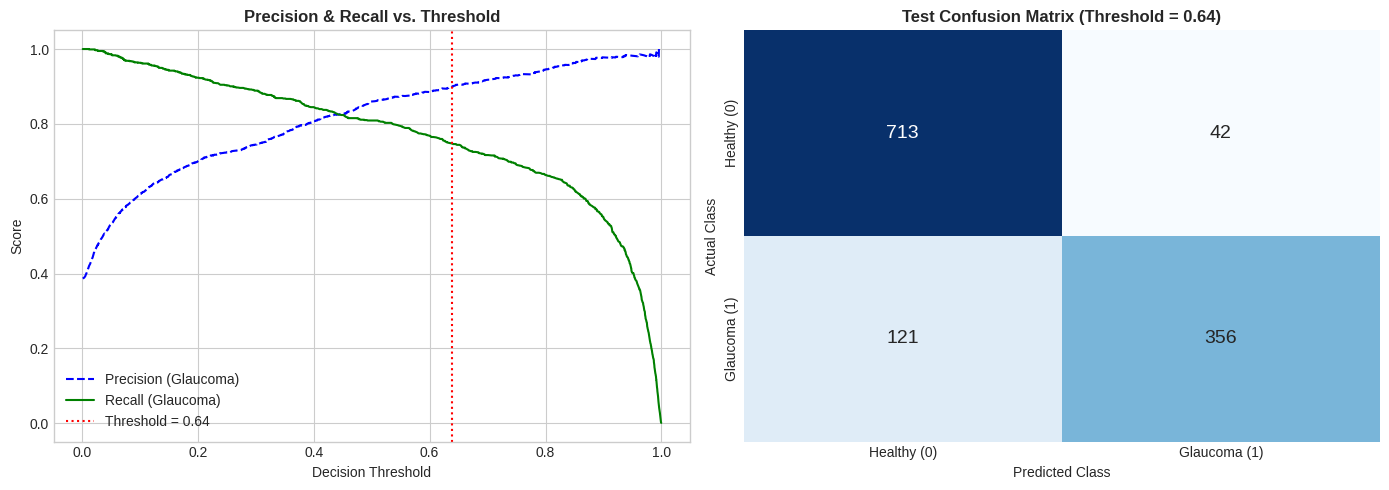


 CALIBRATED TEST REPORT (Threshold = 0.6394)
              precision    recall  f1-score   support

 Healthy (0)       0.85      0.94      0.90       755
Glaucoma (1)       0.89      0.75      0.81       477

    accuracy                           0.87      1232
   macro avg       0.87      0.85      0.86      1232
weighted avg       0.87      0.87      0.87      1232



In [32]:
# ==============================================================================
# THRESHOLD CALIBRATION & CLINICAL OPTIMIZATION
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix
import seaborn as sns

# 1. Extract Validation Probabilities
val_preds, val_labels = [], []
densenet_model.eval()

with torch.no_grad():
    for images, labels in val_cls_loader:
        images = images.to(Config.DEVICE)
        probs = torch.sigmoid(densenet_model(images))
        val_preds.extend(probs.cpu().numpy().flatten())
        val_labels.extend(labels.numpy().flatten())

val_preds = np.array(val_preds)
val_labels = np.array(val_labels)

# 2. Compute Precision-Recall Curve
precisions, recalls, thresholds = precision_recall_curve(val_labels, val_preds)

# Find optimal threshold where Precision >= 0.90
target_precision = 0.90
valid_indices = np.where(precisions[:-1] >= target_precision)[0]

if len(valid_indices) > 0:
    opt_idx = valid_indices[0] # Pick the threshold that gives highest recall while precision >= 0.90
    best_threshold = thresholds[opt_idx]
    print(f"[OPTIMAL] Chosen Threshold: {best_threshold:.4f}")
    print(f"  → Expected Val Precision: {precisions[opt_idx]:.4f}")
    print(f"  → Expected Val Recall:    {recalls[opt_idx]:.4f}")
else:
    # Fallback to threshold that maximizes F1 score
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_threshold = thresholds[np.argmax(f1_scores)]
    print(f"[INFO] 90% Precision not achievable on Val without severe recall drop.")
    print(f"[OPTIMAL] Best F1 Threshold: {best_threshold:.4f}")

# 3. Apply Calibrated Threshold on Unseen Test Set
test_bin_preds = (test_preds >= best_threshold).astype(int)
cm_opt = confusion_matrix(test_labels, test_bin_preds)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Precision-Recall Trade-off
axes[0].plot(thresholds, precisions[:-1], "b--", label="Precision (Glaucoma)")
axes[0].plot(thresholds, recalls[:-1], "g-", label="Recall (Glaucoma)")
axes[0].axvline(best_threshold, color="r", linestyle=":", label=f"Threshold = {best_threshold:.2f}")
axes[0].set_xlabel("Decision Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Precision & Recall vs. Threshold", fontweight="bold")
axes[0].legend(loc="best")
axes[0].grid(True)

# Confusion Matrix with Calibrated Threshold
sns.heatmap(cm_opt, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Healthy (0)", "Glaucoma (1)"], 
            yticklabels=["Healthy (0)", "Glaucoma (1)"], ax=axes[1], annot_kws={"size": 14})
axes[1].set_title(f"Test Confusion Matrix (Threshold = {best_threshold:.2f})", fontweight="bold")
axes[1].set_xlabel("Predicted Class")
axes[1].set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

print("\n" + "="*55)
print(f" CALIBRATED TEST REPORT (Threshold = {best_threshold:.4f})")
print("="*55)
print(classification_report(test_labels, test_bin_preds, target_names=["Healthy (0)", "Glaucoma (1)"]))
print("="*55)

In [34]:
# ==============================================================================
# CELL 11: COST-SENSITIVE FINE-TUNING (RECALL/PRECISION BOOST)
# ==============================================================================
import os

FINETUNED_MODEL_PATH = "finetuned_densenet_glaucoma.pth"

print(f"[SETUP] Reloading original best weights from {Config.DENSENET_SAVE_NAME}...")
densenet_model.load_state_dict(torch.load(Config.DENSENET_SAVE_NAME, map_location=Config.DEVICE))

# 1. Create the Weighted Loss Function (Penalizes False Negatives 1.6x harder)
pos_weight = torch.tensor([1.6], device=Config.DEVICE)
criterion_ft = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# 2. Microscopic Learning Rate to prevent catastrophic forgetting
optimizer_ft = torch.optim.AdamW(densenet_model.parameters(), lr=1e-5, weight_decay=1e-4)

# 3. Short Fine-Tuning Loop
FT_EPOCHS = 3
best_ft_auc = 0.0

print(f"\n[TRAIN] Starting Phase 3: Fine-Tuning ({FT_EPOCHS} Epochs) - Weighted Loss")

for epoch in range(1, FT_EPOCHS + 1):
    # --- Train Loop ---
    densenet_model.train()
    train_loss = 0.0
    for images, labels in train_cls_loader:
        images, labels = images.to(Config.DEVICE), labels.unsqueeze(1).to(Config.DEVICE)
        
        optimizer_ft.zero_grad()
        logits = densenet_model(images)
        loss = criterion_ft(logits, labels)
        loss.backward()
        optimizer_ft.step()
        
        train_loss += loss.item() * images.size(0)
    train_loss /= len(train_df_cls)

    # --- Validation Loop ---
    densenet_model.eval()
    val_loss = 0.0
    preds, trues = [], []
    with torch.no_grad():
        for images, labels in val_cls_loader:
            images, labels = images.to(Config.DEVICE), labels.unsqueeze(1).to(Config.DEVICE)
            logits = densenet_model(images)
            
            # Note: We track standard validation loss here to compare apples-to-apples
            val_loss += criterion_cls(logits, labels).item() * images.size(0) 
            preds.extend(torch.sigmoid(logits).cpu().numpy().flatten())
            trues.extend(labels.cpu().numpy().flatten())
            
    val_loss /= len(val_df_cls)
    val_auc = roc_auc_score(trues, preds) if len(set(trues)) > 1 else 0.5
    
    print(f"FT Epoch {epoch:02d} | Train Loss (Weighted): {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}")
    
    # --- Checkpoint Saving (NEW FILE) ---
    if val_auc > best_ft_auc:
        best_ft_auc = val_auc
        torch.save(densenet_model.state_dict(), FINETUNED_MODEL_PATH)
        print(f"  ✓ New best weights saved to {FINETUNED_MODEL_PATH}")

print(f"\n[SUCCESS] Fine-tuning complete. Safe checkpoint at: {FINETUNED_MODEL_PATH}")

[SETUP] Reloading original best weights from densenetglaucomaclassificationmodel.pth...

[TRAIN] Starting Phase 3: Fine-Tuning (3 Epochs) - Weighted Loss
FT Epoch 01 | Train Loss (Weighted): 0.3242 | Val Loss: 0.3085 | Val AUC: 0.9394
  ✓ New best weights saved to finetuned_densenet_glaucoma.pth
FT Epoch 02 | Train Loss (Weighted): 0.3085 | Val Loss: 0.3106 | Val AUC: 0.9368
FT Epoch 03 | Train Loss (Weighted): 0.2936 | Val Loss: 0.3153 | Val AUC: 0.9366

[SUCCESS] Fine-tuning complete. Safe checkpoint at: finetuned_densenet_glaucoma.pth


[STEP 1/3] Loading FINE-TUNED weights from 'finetuned_densenet_glaucoma.pth'...

[STEP 2/3] Starting inference on test set (1232 total images)...
  → Batch [01/39] | Samples: 32/1232 | Batch Time: 0.10s | Elapsed: 1.0s
  → Batch [02/39] | Samples: 64/1232 | Batch Time: 0.10s | Elapsed: 1.9s
  → Batch [03/39] | Samples: 96/1232 | Batch Time: 0.10s | Elapsed: 2.9s
  → Batch [04/39] | Samples: 128/1232 | Batch Time: 0.10s | Elapsed: 3.9s
  → Batch [05/39] | Samples: 160/1232 | Batch Time: 0.10s | Elapsed: 4.9s
  → Batch [06/39] | Samples: 192/1232 | Batch Time: 0.10s | Elapsed: 5.9s
  → Batch [07/39] | Samples: 224/1232 | Batch Time: 0.10s | Elapsed: 6.9s
  → Batch [08/39] | Samples: 256/1232 | Batch Time: 0.10s | Elapsed: 7.9s
  → Batch [09/39] | Samples: 288/1232 | Batch Time: 0.10s | Elapsed: 8.8s
  → Batch [10/39] | Samples: 320/1232 | Batch Time: 0.10s | Elapsed: 9.8s
  → Batch [11/39] | Samples: 352/1232 | Batch Time: 0.10s | Elapsed: 10.8s
  → Batch [12/39] | Samples: 384/1232 | Ba

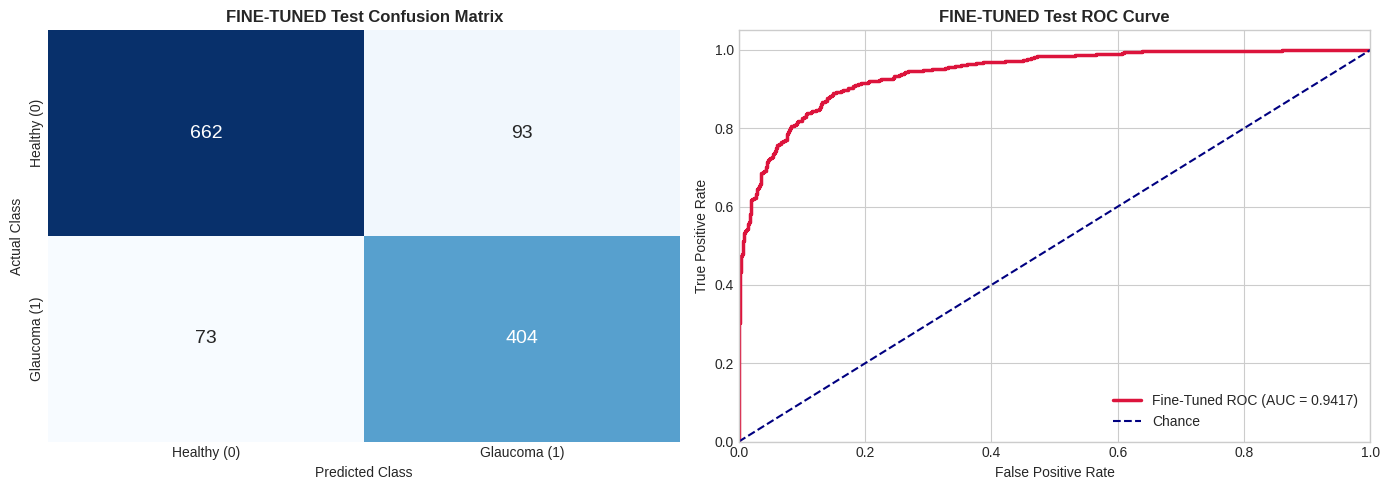


 FINE-TUNED CLINICAL DIAGNOSTIC SUMMARY (TEST SET)
Test ROC-AUC Score        : 0.9417
-------------------------------------------------------
              precision    recall  f1-score   support

 Healthy (0)       0.90      0.88      0.89       755
Glaucoma (1)       0.81      0.85      0.83       477

    accuracy                           0.87      1232
   macro avg       0.86      0.86      0.86      1232
weighted avg       0.87      0.87      0.87      1232



In [37]:
# ==============================================================================
# CELL 12: EVALUATION OF FINE-TUNED DENSENET (TEST SET)
# ==============================================================================
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

FINETUNED_MODEL_PATH = "finetuned_densenet_glaucoma.pth"

print(f"[STEP 1/3] Loading FINE-TUNED weights from '{FINETUNED_MODEL_PATH}'...", flush=True)
if os.path.exists(FINETUNED_MODEL_PATH):
    densenet_model.load_state_dict(torch.load(FINETUNED_MODEL_PATH, map_location=Config.DEVICE))
    densenet_model.eval()
else:
    raise FileNotFoundError(f"Could not find checkpoint: {FINETUNED_MODEL_PATH}. Did Cell 11 finish?")

print(f"\n[STEP 2/3] Starting inference on test set ({len(test_df_cls)} total images)...", flush=True)

ft_test_preds = []
ft_test_labels = []
total_batches = len(test_cls_loader)
start_time = time.time()

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(test_cls_loader, start=1):
        batch_start = time.time()
        
        # Forward pass on GPU
        images = images.to(Config.DEVICE)
        logits = densenet_model(images)
        probs = torch.sigmoid(logits)
        
        ft_test_preds.extend(probs.cpu().numpy().flatten())
        ft_test_labels.extend(labels.numpy().flatten())
        
        batch_time = time.time() - batch_start
        processed_samples = min(batch_idx * Config.CLS_BATCH_SIZE, len(test_df_cls))
        
        print(
            f"  → Batch [{batch_idx:02d}/{total_batches:02d}] "
            f"| Samples: {processed_samples}/{len(test_df_cls)} "
            f"| Batch Time: {batch_time:.2f}s "
            f"| Elapsed: {time.time() - start_time:.1f}s",
            flush=True
        )

ft_test_preds = np.array(ft_test_preds)
ft_test_labels = np.array(ft_test_labels)
ft_bin_preds = (ft_test_preds > 0.5).astype(int)

print(f"\n[STEP 3/3] Inference finished! Rendering Diagnostic Visuals...", flush=True)

# Metrics calculation
ft_auc_score = roc_auc_score(ft_test_labels, ft_test_preds)
ft_fpr, ft_tpr, _ = roc_curve(ft_test_labels, ft_test_preds)
ft_cm = confusion_matrix(ft_test_labels, ft_bin_preds)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix
sns.heatmap(
    ft_cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["Healthy (0)", "Glaucoma (1)"], 
    yticklabels=["Healthy (0)", "Glaucoma (1)"], 
    ax=axes[0], annot_kws={"size": 14}
)
axes[0].set_title("FINE-TUNED Test Confusion Matrix", fontweight="bold")
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("Actual Class")

# 2. ROC Curve
axes[1].plot(ft_fpr, ft_tpr, color="crimson", lw=2.5, label=f"Fine-Tuned ROC (AUC = {ft_auc_score:.4f})")
axes[1].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Chance")
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_title("FINE-TUNED Test ROC Curve", fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# Final Summary Report
print("\n" + "="*55)
print(" FINE-TUNED CLINICAL DIAGNOSTIC SUMMARY (TEST SET)")
print("="*55)
print(f"Test ROC-AUC Score        : {ft_auc_score:.4f}")
print("-" * 55)
print(classification_report(ft_test_labels, ft_bin_preds, target_names=["Healthy (0)", "Glaucoma (1)"]))
print("="*55, flush=True)